<a href="https://colab.research.google.com/github/EnricoABM/umc-ia/blob/main/An%C3%A1lise_das_bibliotecas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Enrico de Andrade Bertozzi Miranda RGM: 11231100657

Curso: Engenharia de Software

Disciplina: Inteligência Artificial

Turma: 6A

Professor: Dr. Fabiano Bezerra Menegidio

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OrdinalEncoder
RANDOM_STATE = 42

dtree_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_param_grid = dtree_param_grid.copy()
rf_param_grid['n_estimators'] = [50, 100]

svm_param_grid = {
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1, 1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Iris

## Importando Dataset

In [4]:
# Importando Dataset
iris = datasets.load_iris()

# Dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Separação dos dados

In [5]:
# Separação dos dados
X = df.drop(columns='species')
Y = df['species']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f"Original: X{X.shape} - Y{Y.shape}")
print(f"Treino: X{X_train.shape} - Y{Y_train.shape}")
print(f"Teste: X{X_test.shape} - Y{Y_test.shape}")


Original: X(150, 4) - Y(150,)
Treino: X(120, 4) - Y(120,)
Teste: X(30, 4) - Y(30,)


## Decision Tree

In [6]:
# Treino do Decision Tree
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)

dtree.fit(X_train, Y_train)

dtree_y_pred = dtree.predict(X_test)

In [7]:
# Métricas do Decision Tree

dtree_acc = accuracy_score(Y_test, dtree_y_pred)
dtree_precision = classification_report(Y_test, dtree_y_pred)

print(f'Acurácia: {dtree_acc:.2f}')
print(dtree_precision)


Acurácia: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Random Forest

In [8]:
# Treino do Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, Y_train)

rf_y_pred = rf.predict(X_test)

In [9]:
# Métricas do modelo

rf_acc = accuracy_score(Y_test, rf_y_pred)
rf_precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {rf_acc:.2f}')
print(rf_precision)


Acurácia: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## GridSearchCV

In [10]:
# Grid Search Random Forest
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=5, scoring='accuracy')

gs_rf.fit(X_train, Y_train)

gs_rf_y_pred = gs_rf.predict(X_test)


In [11]:
# Melhores parâmetros
best_rf_params = gs_rf.best_params_
best_rf_score = gs_rf.best_score_

best_rf_params, best_rf_score

({'max_depth': 3,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 50},
 np.float64(0.95))

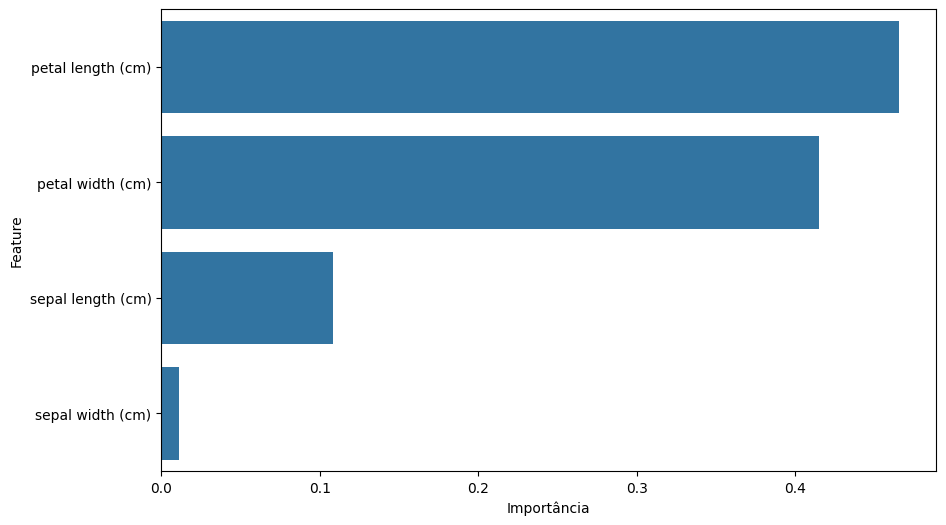

In [12]:
# Importância dos atributos
best_rf = gs_rf.best_estimator_
importances = pd.DataFrame(
    best_rf.feature_importances_,
    index=X.columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.Importance[:10], y=importances.index[:10])
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

# Mushroom

## Importação do Dataset

In [13]:
# Importação do dados
df = pd.read_csv("mushroom_s7_all_features_ohe.csv")

df.head()

,cap-shape__b,cap-shape__c,cap-shape__f,cap-shape__k,cap-shape__s,cap-shape__x,cap-surface__f,cap-surface__g,cap-surface__s,cap-surface__y,...,population__v,population__y,habitat__d,habitat__g,habitat__l,habitat__m,habitat__p,habitat__u,habitat__w,class
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,p
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,e
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,e
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,p
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,e


## Separação dos dados

In [14]:
# Separação dos dados
X = df.drop(columns='class')
Y = df['class']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f"Original: X{X.shape} - Y{Y.shape}")
print(f"Treino: X{X_train.shape} - Y{Y_train.shape}")
print(f"Teste: X{X_test.shape} - Y{Y_test.shape}")

Original: X(8124, 117) - Y(8124,)
Treino: X(6499, 117) - Y(6499,)
Teste: X(1625, 117) - Y(1625,)


## Decision Tree

In [15]:
# Treinando Decision Tree
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)

dtree.fit(X_train, Y_train)

dtree_y_pred = dtree.predict(X_test)

In [16]:
# Métricas do modelo

dtree_acc = accuracy_score(Y_test, dtree_y_pred)
dtree_precision = classification_report(Y_test, dtree_y_pred)

print(f'Acurácia: {dtree_acc:.2f}')
print(dtree_precision)

Acurácia: 1.00
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       843
           p       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



## Random Forest

In [17]:
# Treino do Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, Y_train)

rf_y_pred = rf.predict(X_test)

In [18]:
# Métricas do Random Forest

rf_acc = accuracy_score(Y_test, rf_y_pred)
rf_precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {rf_acc:.2f}')
print(rf_precision)

Acurácia: 1.00
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       843
           p       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



## GridSearchCV

In [19]:
# Grid Search Random Forest
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=5, scoring='accuracy')

gs_rf.fit(X_train, Y_train)

gs_rf_y_pred = gs_rf.predict(X_test)

In [20]:
# Melhores parâmetros
best_rf_params = gs_rf.best_params_
best_rf_score = gs_rf.best_score_

best_rf_params, best_rf_score

({'max_depth': 10,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 50},
 np.float64(1.0))

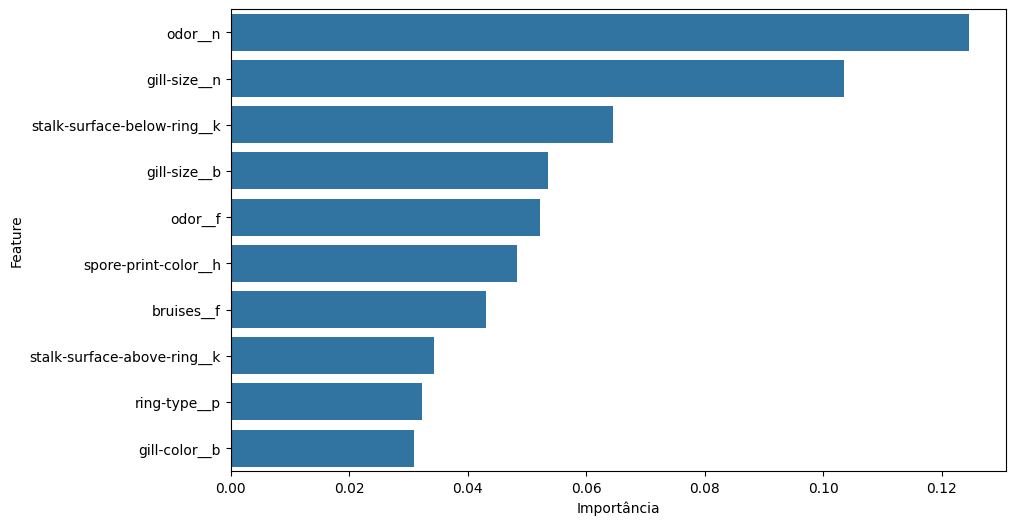

In [21]:
# Importância dos atributos
best_rf = gs_rf.best_estimator_
importances = pd.DataFrame(
    best_rf.feature_importances_,
    index=X.columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.Importance[:10], y=importances.index[:10])
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

# Autistic Spectrum Disorder

## Importação do Dataset

In [22]:
# Importação do Dataset
df = pd.read_csv("ASD_meta_abundance_discretized.csv")

df.head()

,Unnamed: 0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,g__Hungatella;s__Hungatella hathewayi,g__Clostridium;s__uncultured Clostridium sp.,g__Butyricimonas;s__Butyricimonas virosa,g__Alistipes;s__Alistipes indistinctus,g__Unclassified;s__Firmicutes bacterium CAG:176,g__Clostridium;s__Clostridium sp. CAG:7,g__Unclassified;s__Firmicutes bacterium CAG:882,g__Lachnoclostridium;s__[Clostridium] asparagiforme,...,g__Unclassified;s__Clostridium phage c-st,g__Unclassified;s__Enterococcus phage EFDG1,g__Unclassified;s__Podovirus Lau218,g__Sap6virus;s__Enterococcus phage VD13,g__Unclassified;s__Bacillus phage vB_BanS-Tsamsa,g__Unclassified;s__Gordonia phage GTE2,g__Alphabaculovirus;s__Hyphantria cunea nucleopolyhedrovirus,g__Potyvirus;s__Bean common mosaic virus,g__Potyvirus;s__Telosma mosaic virus,g__Unclassified;s__Freshwater phage uvFW-CGR-AMD-COM-C203
0,A3,mid,high,mid,low,low,low,high,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
1,A5,mid,high,low,mid,low,low,mid,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
2,A6,low,mid,low,low,low,low,mid,low,high,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
3,A9,mid,low,high,mid,low,mid,high,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
4,A31,mid,low,high,low,high,low,mid,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent


## Pré-Processamento

In [23]:
# Remoção dos números presentes nos rotulos
df['Unnamed: 0'] = df['Unnamed: 0'].map(lambda x: x[0])


# Enconding dos dados
order = ['absent', 'present', 'low', 'mid', 'high']

data_df = df.drop(columns='Unnamed: 0')

encoder = OrdinalEncoder(
    # Uso de List Compreension para definir ordem de todas as colunas
    categories=[order for n in data_df],
    handle_unknown='use_encoded_value',
    unknown_value=-1)

data = encoder.fit_transform(data_df)
ord_columns = data_df.columns

# # Novo DataFrame com dados transformados
data_df = pd.DataFrame(data, columns=ord_columns)

# Visualização
data_df.head()

,g__Faecalibacterium;s__Faecalibacterium prausnitzii,g__Hungatella;s__Hungatella hathewayi,g__Clostridium;s__uncultured Clostridium sp.,g__Butyricimonas;s__Butyricimonas virosa,g__Alistipes;s__Alistipes indistinctus,g__Unclassified;s__Firmicutes bacterium CAG:176,g__Clostridium;s__Clostridium sp. CAG:7,g__Unclassified;s__Firmicutes bacterium CAG:882,g__Lachnoclostridium;s__[Clostridium] asparagiforme,g__Butyricicoccus;s__uncultured Butyricicoccus sp.,...,g__Unclassified;s__Clostridium phage c-st,g__Unclassified;s__Enterococcus phage EFDG1,g__Unclassified;s__Podovirus Lau218,g__Sap6virus;s__Enterococcus phage VD13,g__Unclassified;s__Bacillus phage vB_BanS-Tsamsa,g__Unclassified;s__Gordonia phage GTE2,g__Alphabaculovirus;s__Hyphantria cunea nucleopolyhedrovirus,g__Potyvirus;s__Bean common mosaic virus,g__Potyvirus;s__Telosma mosaic virus,g__Unclassified;s__Freshwater phage uvFW-CGR-AMD-COM-C203
0,3.0,4.0,3.0,2.0,2.0,2.0,4.0,2.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.0,4.0,2.0,3.0,2.0,2.0,3.0,2.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,3.0,2.0,2.0,2.0,2.0,3.0,2.0,4.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,2.0,4.0,3.0,2.0,3.0,4.0,2.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,2.0,4.0,2.0,4.0,2.0,3.0,2.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Separação dos dados

In [24]:
# Separação dos dados

X = data_df
Y = df['Unnamed: 0']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f"Original: X{X.shape} - Y{Y.shape}")
print(f"Treino: X{X_train.shape} - Y{Y_train.shape}")
print(f"Teste: X{X_test.shape} - Y{Y_test.shape}")

Original: X(60, 5619) - Y(60,)
Treino: X(48, 5619) - Y(48,)
Teste: X(12, 5619) - Y(12,)


## Decision Tree


In [25]:
# Treinando Decision Tree
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)

dtree.fit(X_train, Y_train)

dtree_y_pred = dtree.predict(X_test)

In [26]:
# Métricas do modelo

dtree_acc = accuracy_score(Y_test, dtree_y_pred)
dtree_precision = classification_report(Y_test, dtree_y_pred)

print(f'Acurácia: {dtree_acc:.2f}')
print(dtree_precision)

Acurácia: 0.75
              precision    recall  f1-score   support

           A       0.60      0.75      0.67         4
           B       0.86      0.75      0.80         8

    accuracy                           0.75        12
   macro avg       0.73      0.75      0.73        12
weighted avg       0.77      0.75      0.76        12



## Random Forest

In [27]:
# Treino do Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, Y_train)

rf_y_pred = rf.predict(X_test)

In [28]:
# Métricas do modelo

rf_acc = accuracy_score(Y_test, rf_y_pred)
rf_precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {rf_acc:.2f}')
print(rf_precision)

Acurácia: 0.50
              precision    recall  f1-score   support

           A       0.38      0.75      0.50         4
           B       0.75      0.38      0.50         8

    accuracy                           0.50        12
   macro avg       0.56      0.56      0.50        12
weighted avg       0.62      0.50      0.50        12



## GridSearchCV

In [29]:
# Grid Search Random Forest
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=5, scoring='accuracy')

gs_rf.fit(X_train, Y_train)

gs_rf_y_pred = gs_rf.predict(X_test)

In [30]:
# Melhores parâmetros
best_rf_params = gs_rf.best_params_
best_rf_score = gs_rf.best_score_

best_rf_params, best_rf_score

({'max_depth': 10,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 50},
 np.float64(0.8755555555555556))

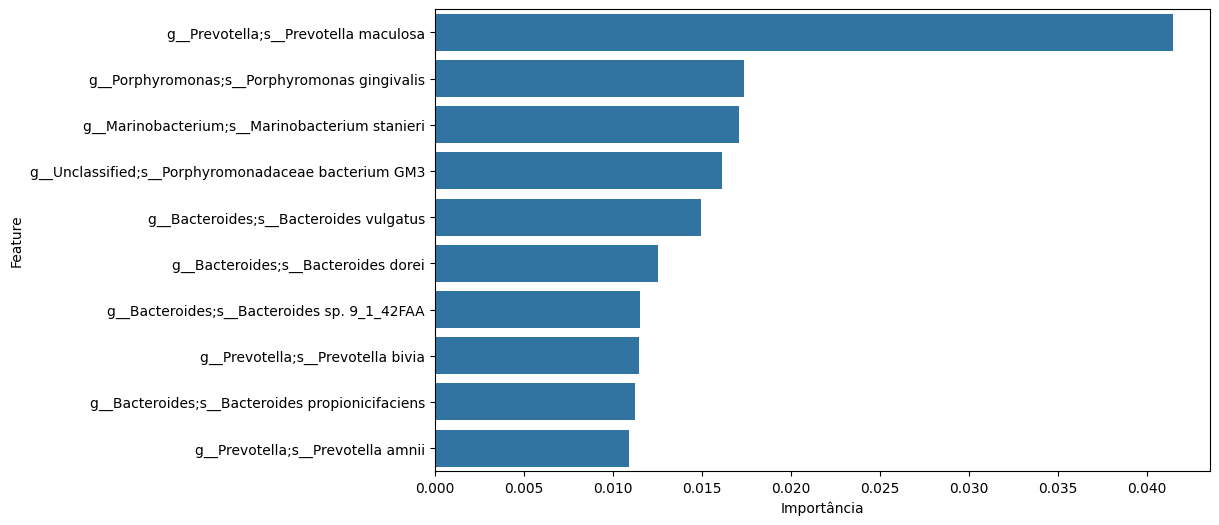

In [31]:
# Importância dos atributos
best_rf = gs_rf.best_estimator_
importances = pd.DataFrame(
    best_rf.feature_importances_,
    index=X.columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.Importance[:10], y=importances.index[:10])
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

# Breast Cancer Wisconsin

## Importação do Dataset

In [32]:
# Importação do Dataset

dataset = datasets.load_breast_cancer()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Pré-Processamento

In [33]:
# Pré Processamento
target_names = dataset.target_names

df['target'] = df['target'].map(lambda x: target_names[0] if x == 0 else target_names[1])

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## Separação dos dados

In [34]:
# Separação dos dados

X = df.drop(columns='target')
Y = df['target']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f"Original: X{X.shape} - Y{Y.shape}")
print(f"Treino: X{X_train.shape} - Y{Y_train.shape}")
print(f"Teste: X{X_test.shape} - Y{Y_test.shape}")

Original: X(569, 30) - Y(569,)
Treino: X(455, 30) - Y(455,)
Teste: X(114, 30) - Y(114,)


## Decision Tree

In [35]:
# Treino do modelo
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)

dtree.fit(X_train, Y_train)

dtree_y_pred = dtree.predict(X_test)

In [36]:
# Métricas do Modelo
acc = accuracy_score(Y_test, dtree_y_pred)
precision = classification_report(Y_test, dtree_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.95
              precision    recall  f1-score   support

      benign       0.96      0.96      0.96        71
   malignant       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## Random Forest

In [37]:
# Treino do Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, Y_train)

rf_y_pred = rf.predict(X_test)

In [38]:
# Métricas do modelo

acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.96
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        71
   malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## GridSearchCV

In [39]:
# Grid Search Random Forest
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=5, scoring='accuracy')

gs_rf.fit(X_train, Y_train)

gs_rf_y_pred = gs_rf.predict(X_test)

In [40]:
# Métricas do modelo

acc = accuracy_score(Y_test, gs_rf_y_pred)
precision = classification_report(Y_test, gs_rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.96
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        71
   malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



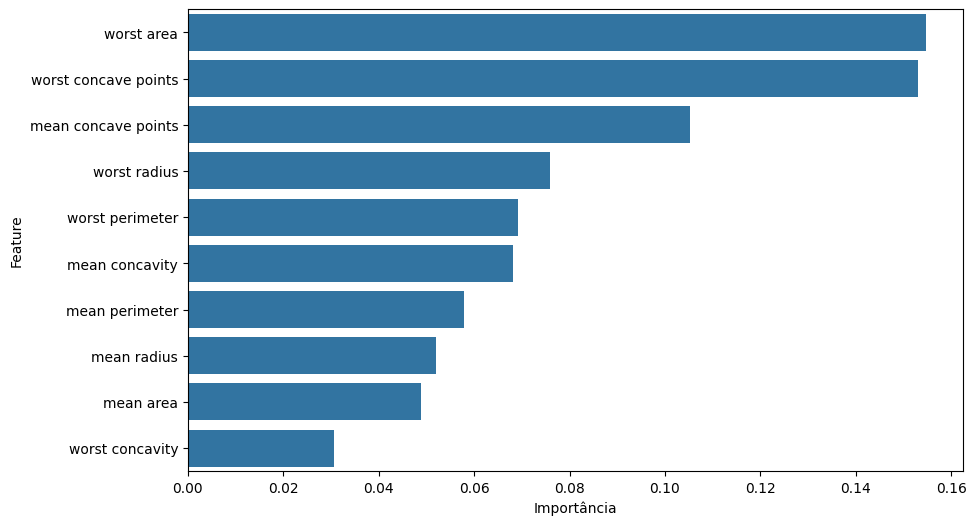

In [41]:
# Importância dos atributos
best_rf = gs_rf.best_estimator_
importances = pd.DataFrame(
    best_rf.feature_importances_,
    index=df.drop(columns='target').columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.Importance[:10], y=importances.index[:10])
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

# Wine

## Importação do Dataset

In [42]:
# Importação do Dataset
dataset = datasets.load_wine()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Pré-Processamento

In [43]:
# Pré Processamento
target_names = dataset.target_names

df['target'] = df['target'].map(lambda x: target_names[x])

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## Separação dos dados

In [44]:
# Separação dos dados

X = df.drop(columns='target')
Y = df['target']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f"Original: X{X.shape} - Y{Y.shape}")
print(f"Treino: X{X_train.shape} - Y{Y_train.shape}")
print(f"Teste: X{X_test.shape} - Y{Y_test.shape}")

Original: X(178, 13) - Y(178,)
Treino: X(142, 13) - Y(142,)
Teste: X(36, 13) - Y(36,)


## Decision Tree

In [45]:
# Treino do modelo
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)

dtree.fit(X_train, Y_train)

dtree_y_pred = dtree.predict(X_test)

In [46]:
# Métricas do modelo

acc = accuracy_score(Y_test, dtree_y_pred)
precision = classification_report(Y_test, dtree_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.94
              precision    recall  f1-score   support

     class_0       0.93      0.93      0.93        14
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



## Random Forest

In [47]:
# Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, Y_train)

rf_y_pred = rf.predict(X_test)

In [48]:
# Métricas do modelo

acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 1.00
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## GridSearchCV

In [49]:
# GridSearchCV

gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=5, scoring='accuracy')

gs_rf.fit(X_train, Y_train)

gs_rf_y_pred = gs_rf.predict(X_test)

In [50]:
# Métricas do modelo

acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 1.00
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



#

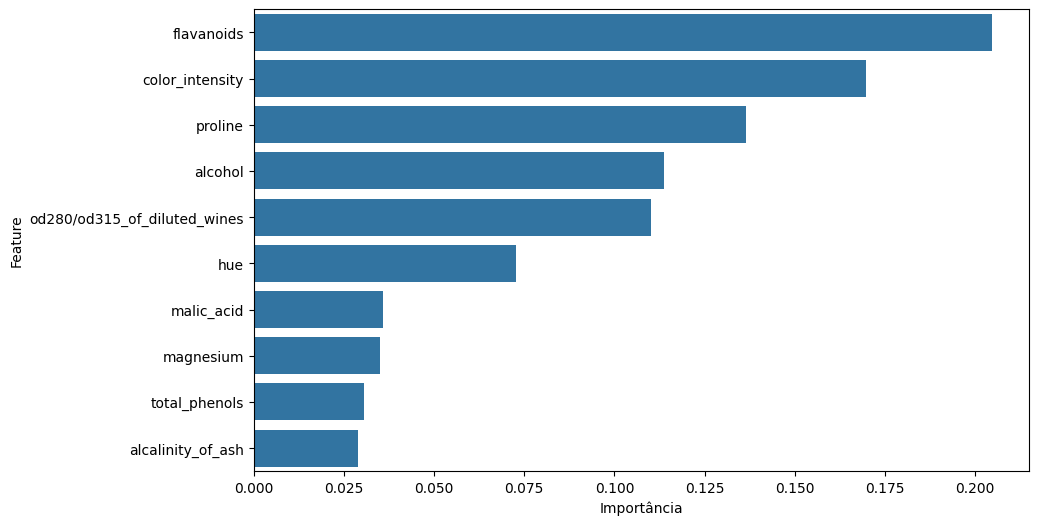

In [51]:
# Importância dos atributos
best_rf = gs_rf.best_estimator_
importances = pd.DataFrame(
    best_rf.feature_importances_,
    index=df.drop(columns='target').columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.Importance[:10], y=importances.index[:10])
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

# Pima Indians Diabetes

## Importação do Dataset

In [2]:
# Importação do Dataset
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Pré-Processamento

In [3]:
# Pré Processamento

df['Outcome'] = df['Outcome'].map(lambda x: 'positive' if x == 1 else 'negative')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,positive
1,1,85,66,29,0,26.6,0.351,31,negative
2,8,183,64,0,0,23.3,0.672,32,positive
3,1,89,66,23,94,28.1,0.167,21,negative
4,0,137,40,35,168,43.1,2.288,33,positive


## Separação dos dados

In [4]:
# Separação dos dados

X = df.drop(columns='Outcome')
Y = df['Outcome']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f"Original: X{X.shape} - Y{Y.shape}")
print(f"Treino: X{X_train.shape} - Y{Y_train.shape}")
print(f"Teste: X{X_test.shape} - Y{Y_test.shape}")

Original: X(768, 8) - Y(768,)
Treino: X(614, 8) - Y(614,)
Teste: X(154, 8) - Y(154,)


## SVM

In [5]:
# Treino do Modelo
svm = SVC(random_state=RANDOM_STATE, kernel='linear')

svm.fit(X_train, Y_train)

svm_y_pred = svm.predict(X_test)

In [6]:
# Métricas do modelo

acc = accuracy_score(Y_test, svm_y_pred)

print(f'Acurácia: {acc:.2f}')

Acurácia: 0.75


## Decision Tree

In [7]:
# Treino do Modelo
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)

dtree.fit(X_train, Y_train)

dtree_y_pred = dtree.predict(X_test)

In [8]:
# Métricas do Modelo

acc = accuracy_score(Y_test, dtree_y_pred)
precision = classification_report(Y_test, dtree_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.75
              precision    recall  f1-score   support

    negative       0.83      0.76      0.79        99
    positive       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



## Random Forest

In [9]:
# Treino do modelo

rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, Y_train)

rf_y_pred = rf.predict(X_test)

In [10]:
# Métricas do modelo

acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.72
              precision    recall  f1-score   support

    negative       0.79      0.78      0.78        99
    positive       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



## Random Forest GridSearchCV

In [11]:
# GridSearchCV

gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, cv=5, scoring='accuracy')

gs_rf.fit(X_train, Y_train)

gs_rf_y_pred = gs_rf.predict(X_test)

In [12]:
# Métricas do modelo

acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.72
              precision    recall  f1-score   support

    negative       0.79      0.78      0.78        99
    positive       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



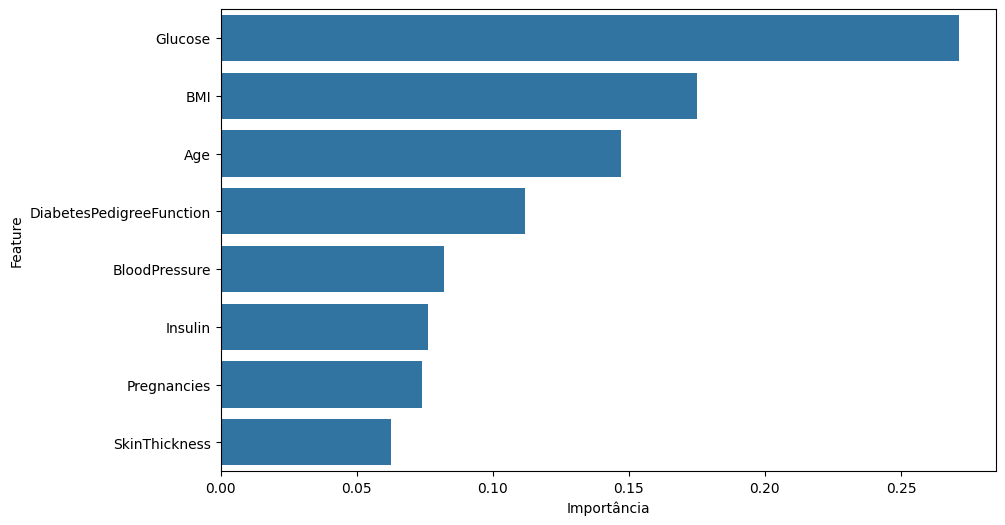

In [13]:
# Importância dos atributos
best_rf = gs_rf.best_estimator_
importances = pd.DataFrame(
    best_rf.feature_importances_,
    index=X.columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.Importance[:10], y=importances.index[:10])
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

## SVM GridSearchCV

In [14]:
# Grid Search

gs_svm = GridSearchCV(SVC(random_state=RANDOM_STATE), svm_param_grid, cv=cv, scoring='accuracy')

gs_svm.fit(X_train, Y_train)

gs_svm_y_pred = gs_svm.predict(X_test)

In [15]:
# Métricas do modelo

acc = accuracy_score(Y_test, svm_y_pred)

print(f'Acurácia: {acc:.2f}')

Acurácia: 0.75


# FISHMORPH Dataset Family

## Importação do Dataset

In [16]:
# Importação do Dataset
df = pd.read_csv("FISHMORPH_Family_Dataset.csv")

df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Family
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cyprinidae
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Cichlidae
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cyprinidae
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cyprinidae
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cyprinidae


## Separação dos dados

In [17]:
# Separação dos dados

X = df.drop(columns='Family')
Y = df['Family']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f"Original: X{X.shape} - Y{Y.shape}")
print(f"Treino: X{X_train.shape} - Y{Y_train.shape}")
print(f"Teste: X{X_test.shape} - Y{Y_test.shape}")

Original: X(8342, 10) - Y(8342,)
Treino: X(6673, 10) - Y(6673,)
Teste: X(1669, 10) - Y(1669,)


## SVM

In [18]:
# Treino do modelo
svm = SVC(random_state=RANDOM_STATE, kernel='linear')

svm.fit(X_train, Y_train)

svm_y_pred = svm.predict(X_test)

In [19]:
# Métricas do modelo

acc = accuracy_score(Y_test, svm_y_pred)

print(f'Acurácia: {acc:.2f}')

Acurácia: 0.54


## Decision Tree


In [20]:
# Treino do modelo
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)

dtree.fit(X_train, Y_train)

dtree_y_pred = dtree.predict(X_test)

In [21]:
# Métricas do modelo

acc = accuracy_score(Y_test, dtree_y_pred)
precision = classification_report(Y_test, dtree_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.47
                     precision    recall  f1-score   support

     Abyssocottidae       0.00      0.00      0.00         3
  Acestrorhynchidae       0.00      0.00      0.00         3
          Achiridae       0.00      0.00      0.00         3
      Acipenseridae       1.00      0.60      0.75         5
   Adrianichthyidae       0.00      0.00      0.00         1
           Akysidae       0.00      0.00      0.00         1
          Alestidae       0.38      0.28      0.32        18
         Ambassidae       0.00      0.00      0.00         4
     Amblycipitidae       0.14      1.00      0.25         1
       Amblyopsidae       0.00      0.00      0.00         0
       Ambylopsidae       0.00      0.00      0.00         1
            Amiidae       0.00      0.00      0.00         0
        Amphiliidae       0.36      0.62      0.45         8
        Anabantidae       0.00      0.00      0.00         6
        Anablepidae       0.00      0.00      0.00         0
        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

## Random Forest

In [22]:
# Treinando o modelo

rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, Y_train)

rf_y_pred = rf.predict(X_test)

In [23]:
# Métricas do modelo

acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

Acurácia: 0.61
                     precision    recall  f1-score   support

     Abyssocottidae       0.00      0.00      0.00         3
  Acestrorhynchidae       1.00      1.00      1.00         3
          Achiridae       0.00      0.00      0.00         3
      Acipenseridae       0.75      0.60      0.67         5
   Adrianichthyidae       0.00      0.00      0.00         1
           Akysidae       0.33      1.00      0.50         1
          Alestidae       0.00      0.00      0.00        18
         Ambassidae       0.67      0.50      0.57         4
     Amblycipitidae       0.00      0.00      0.00         1
       Ambylopsidae       0.00      0.00      0.00         1
        Amphiliidae       0.50      0.75      0.60         8
        Anabantidae       0.00      0.00      0.00         6
        Anablepidae       0.00      0.00      0.00         0
        Anguillidae       1.00      1.00      1.00         2
        Anostomidae       0.50      0.04      0.08        24
      Ap

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

## Random Forest GridSearchCV

In [ ]:
# GridSearchCV

gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, scoring='accuracy')

gs_rf.fit(X_train, Y_train)

gs_rf_y_pred = gs_rf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
# Métricas do modelo

acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

In [ ]:
# Importância dos atributos
best_rf = gs_rf.best_estimator_
importances = pd.DataFrame(
    best_rf.feature_importances_,
    index=df.drop(columns='target').columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.Importance[:10], y=importances.index[:10])
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

## SVM Grid Search

In [ ]:
# Grid Search CV
gs_svm = GridSearchCV(SVC(random_state=RANDOM_STATE), svm_param_grid, cv=cv, scoring='accuracy')

gs_svm.fit(X_train, Y_train)

gs_svm_y_pred = gs_svm.predict(X_test)

In [ ]:
# Métricas do modelo

acc = accuracy_score(Y_test, svm_y_pred)

print(f'Acurácia: {acc:.2f}')

# FISHMORPH Dataset Order

## Importação do Dataset

In [ ]:
# Importação do Dataset
df = pd.read_csv("FISHMORPH_Order_Dataset.csv")

df.head()

## Separação dos dados

In [ ]:
# Separação dos dados

X = df.drop(columns='Order')
Y = df['Order']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f"Original: X{X.shape} - Y{Y.shape}")
print(f"Treino: X{X_train.shape} - Y{Y_train.shape}")
print(f"Teste: X{X_test.shape} - Y{Y_test.shape}")

## SVM

In [ ]:
# Treino do modelo
svm = SVC(random_state=RANDOM_STATE, kernel='linear')

svm.fit(X_train, Y_train)

svm_y_pred = svm.predict(X_test)

In [ ]:
# Métricas do modelo

acc = accuracy_score(Y_test, svm_y_pred)

print(f'Acurácia: {acc:.2f}')

## Decision Tree

In [ ]:
# Treino do modelo
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)

dtree.fit(X_train, Y_train)

dtree_y_pred = dtree.predict(X_test)

In [ ]:
# Métricas do modelo

acc = accuracy_score(Y_test, dtree_y_pred)
precision = classification_report(Y_test, dtree_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

## Random Florest

In [ ]:
# Treino do modelo
rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, Y_train)

rf_y_pred = rf.predict(X_test)

In [ ]:
# Métricas do modelo

acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

## Random Florest GridSearchCV

In [ ]:
# Grid Search CV
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid, scoring='accuracy')

gs_rf.fit(X_train, Y_train)

gs_rf_y_pred = gs_rf.predict(X_test)

In [ ]:
# Métricas do modelo
acc = accuracy_score(Y_test, rf_y_pred)
precision = classification_report(Y_test, rf_y_pred)

print(f'Acurácia: {acc:.2f}')
print(precision)

In [ ]:
# Importância dos atributos
best_rf = gs_rf.best_estimator_
importances = pd.DataFrame(
    best_rf.feature_importances_,
    index=df.drop(columns='target').columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.Importance[:10], y=importances.index[:10])
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

## SVM GridSearchCV

In [ ]:
# Grid Search CV
gs_svm = GridSearchCV(SVC(random_state=RANDOM_STATE), svm_param_grid, cv=cv, scoring='accuracy')

gs_svm.fit(X_train, Y_train)

gs_svm_y_pred = gs_svm.predict(X_test)

In [ ]:
# Métricas do modelo

acc = accuracy_score(Y_test, svm_y_pred)

print(f'Acurácia: {acc:.2f}')